# sentiment_calibration — Decomposizione BALD sul source model sentiment (electronics)

Stesso schema del Notebook 9 (`code_v2/notebooks/09_digits_bald.ipynb`), applicato al source
model sentiment (`amazon_reviews/train.py`, verificato da `amazon_reviews/verify_source.py`)
invece che ai digit. Questa testa ha **K=2** classi (positive/negative) e **Dp=65**
(feature_dim=64 + bias) -- dimensione K·Dp=130, molto più piccola di quella dei digit
(K·Dp=1.290): nessun problema di scala per l'Hessiana, ma il controllo di convergenza Monte
Carlo va comunque rifatto da zero (M_FIXED di altri esperimenti non è riusabile: la
dimensione della testa e la scala dei logit sono diverse).

**Target**: dvd, kitchen, books (tutti vettorizzati con lo STESSO vocabolario/IDF fittato solo
su electronics train -- nessun rifit per dominio, coerente con `data_utils.transform_tfidf`).
È esattamente qui che vive lo shift lessicale: parole frequenti in un target ma assenti dal
vocabolario del source producono feature TF-IDF nulle o quasi su quelle dimensioni.

## 1. Caricamento del source model verificato e dei domini target

In [ ]:
import sys, pickle
from pathlib import Path

sys.path.insert(0, "amazon_reviews")
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from data_utils import load_domain, stratified_split, transform_tfidf
from model import build_model
from code_v2.src.bayesian_model import extract, augment, head_weights, LastLayerLaplace

CHECKPOINT_DIR = Path("amazon_reviews") / "models" / "source_electronics"
ckpt = torch.load(CHECKPOINT_DIR / "model.pt", map_location="cpu", weights_only=False)
with open(CHECKPOINT_DIR / "tfidf_transformer.pkl", "rb") as f:
    transformer = pickle.load(f)
vocab = ckpt["vocab"]

model = build_model()
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"source model verificato caricato (amazon_reviews/verify_source.py: PASS su tutti i domini) "
      f"-- vocabolario {len(vocab)} termini")

SOURCE_DOMAIN = "electronics"
TARGET_DOMAINS = ["dvd", "kitchen", "books"]
VAL_FRACTION, TEST_FRACTION, SEED = 0.15, 0.15, ckpt["seed"]

counts_source, labels_source = load_domain(SOURCE_DOMAIN)
train_idx, val_idx, test_idx = stratified_split(labels_source, VAL_FRACTION, TEST_FRACTION, SEED)

def to_loader(counts_list, labels, idx=None):
    if idx is not None:
        counts_list = [counts_list[i] for i in idx]
        labels = labels[idx]
    X_sparse = transform_tfidf(counts_list, vocab, transformer)
    X = torch.tensor(X_sparse.toarray(), dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=256, shuffle=False)

# feature del TRAIN split del source -- serviranno al fit di Laplace (Sezione 2)
train_loader = to_loader(counts_source, labels_source, train_idx)
Phi_train, y_train, _ = extract(model, train_loader, device="cpu")
print(f"electronics train (per il fit di Laplace): {Phi_train.shape[0]} recensioni, feature {Phi_train.shape}")

# feature del TEST split del source (vero held-out) + dei tre target -- per la Sezione 4
EVAL_DOMAINS = ["electronics"] + TARGET_DOMAINS
DOMAIN_LABELS = {"electronics": "electronics (source, held-out test)", "dvd": "dvd (target)",
                 "kitchen": "kitchen (target)", "books": "books (target)"}

Phi_aug_eval, y_eval = {}, {}
test_loader = to_loader(counts_source, labels_source, test_idx)
Phi_test, y_test_np, _ = extract(model, test_loader, device="cpu")
Phi_aug_eval["electronics"] = augment(Phi_test)
y_eval["electronics"] = y_test_np
print(f"{DOMAIN_LABELS['electronics']}: {Phi_test.shape[0]} recensioni, feature {Phi_test.shape}")

for domain in TARGET_DOMAINS:
    counts_t, labels_t = load_domain(domain)
    loader_t = to_loader(counts_t, labels_t)
    Phi_t, y_t_np, _ = extract(model, loader_t, device="cpu")
    Phi_aug_eval[domain] = augment(Phi_t)
    y_eval[domain] = y_t_np
    print(f"{DOMAIN_LABELS[domain]}: {Phi_t.shape[0]} recensioni, feature {Phi_t.shape}")

source model verificato caricato (amazon_reviews/verify_source.py: PASS su tutti i domini) -- vocabolario 5000 termini
electronics train (per il fit di Laplace): 1400 recensioni, feature (1400, 64)
electronics (source, held-out test): 300 recensioni, feature (300, 64)
dvd (target): 2000 recensioni, feature (2000, 64)
kitchen (target): 2000 recensioni, feature (2000, 64)
books (target): 2000 recensioni, feature (2000, 64)


## 2. Fit di Laplace sulle feature di electronics train

`tau_prior = weight_decay * N_source`, con `N_source` = dimensione del TRAIN split usato per
il MAP training (1.400 recensioni, non le 2.000 totali del dominio) -- stessa convenzione già
in uso in tutta la pipeline (`code_v2/src/digits_train.py`, `amazon_reviews/train.py`).

In [ ]:
Phi_aug_train = augment(Phi_train)
W_aug = head_weights(model)
WEIGHT_DECAY = ckpt["weight_decay"]
N_source = Phi_train.shape[0]
tau_prior = WEIGHT_DECAY * N_source

laplace = LastLayerLaplace.fit(W_aug, Phi_aug_train, tau_prior=tau_prior)
print(f"laplace: K={laplace.K} Dp={laplace.Dp} cov shape={laplace.cov.shape}  "
      f"tau_prior={tau_prior} (weight_decay={WEIGHT_DECAY} * N_source={N_source})")

laplace: K=2 Dp=65 cov shape=(130, 130)  tau_prior=1.4000000000000001 (weight_decay=0.001 * N_source=1400)


## 3. Controllo di convergenza epistemica vs. M (ricalcolato da zero)

K=2, Dp=65 -- dimensione della testa completamente diversa dai digit (K=10, Dp=129) e da
MNIST (K=10, Dp=129): nessun `M_FIXED` di altri esperimenti viene riusato qui. Stesso
protocollo già in uso: sweep di `M_VALUES` a seed fisso, confrontato con un riferimento
indipendente `M_REFERENCE` (stesso seed, non incluso in `M_VALUES`), soglia relativa (1%) +
assoluta (2% del massimo osservato), finestra di stabilità di 3 valori consecutivi, su tutti
e quattro i domini simultaneamente.

In [ ]:
M_VALUES = [50, 100, 250, 500, 1000, 2000, 3000, 4000]
RNG_SEED = 123

convergence = {f"{d}_{stat}": [] for d in EVAL_DOMAINS for stat in ["total", "epi", "ale"]}
convergence["M"] = []

for M in M_VALUES:
    convergence["M"].append(M)
    line = [f"M={M:5d}:"]
    for domain in EVAL_DOMAINS:
        rng = np.random.default_rng(RNG_SEED)
        pred = laplace.predictive_batched(Phi_aug_eval[domain], M=M, rng=rng)
        convergence[f"{domain}_total"].append(pred["total"].mean())
        convergence[f"{domain}_epi"].append(pred["epistemic"].mean())
        convergence[f"{domain}_ale"].append(pred["aleatoric"].mean())
        line.append(f"{domain}_epi={pred['epistemic'].mean():.4f}")
    print("  " + "  ".join(line))

M_REFERENCE = 5000
ref_epi = {}
for domain in EVAL_DOMAINS:
    rng = np.random.default_rng(RNG_SEED)
    pred_ref = laplace.predictive_batched(Phi_aug_eval[domain], M=M_REFERENCE, rng=rng)
    ref_epi[domain] = pred_ref["epistemic"].mean()
    print(f"  {domain}: riferimento epistemica (M={M_REFERENCE}) = {ref_epi[domain]:.6f}")

epi_max = max(list(ref_epi.values()) + sum([convergence[f"{d}_epi"] for d in EVAL_DOMAINS], []))
RELATIVE_THRESHOLD = 0.01
ABSOLUTE_THRESHOLD = 0.02 * epi_max
print(f"\nsoglia assoluta: {ABSOLUTE_THRESHOLD:.6f} (2% del massimo osservato={epi_max:.6f})")

  M=   50:  electronics_epi=0.0036  dvd_epi=0.0050  kitchen_epi=0.0035  books_epi=0.0050
  M=  100:  electronics_epi=0.0031  dvd_epi=0.0043  kitchen_epi=0.0031  books_epi=0.0044
  M=  250:  electronics_epi=0.0029  dvd_epi=0.0041  kitchen_epi=0.0029  books_epi=0.0042
  M=  500:  electronics_epi=0.0029  dvd_epi=0.0040  kitchen_epi=0.0029  books_epi=0.0041
  M= 1000:  electronics_epi=0.0029  dvd_epi=0.0040  kitchen_epi=0.0028  books_epi=0.0041
  M= 2000:  electronics_epi=0.0028  dvd_epi=0.0039  kitchen_epi=0.0028  books_epi=0.0041
  M= 3000:  electronics_epi=0.0028  dvd_epi=0.0040  kitchen_epi=0.0028  books_epi=0.0041
  M= 4000:  electronics_epi=0.0029  dvd_epi=0.0040  kitchen_epi=0.0028  books_epi=0.0041
  electronics: riferimento epistemica (M=5000) = 0.002840
  dvd: riferimento epistemica (M=5000) = 0.003954
  kitchen: riferimento epistemica (M=5000) = 0.002821
  books: riferimento epistemica (M=5000) = 0.004061

soglia assoluta: 0.000100 (2% del massimo osservato=0.005023)


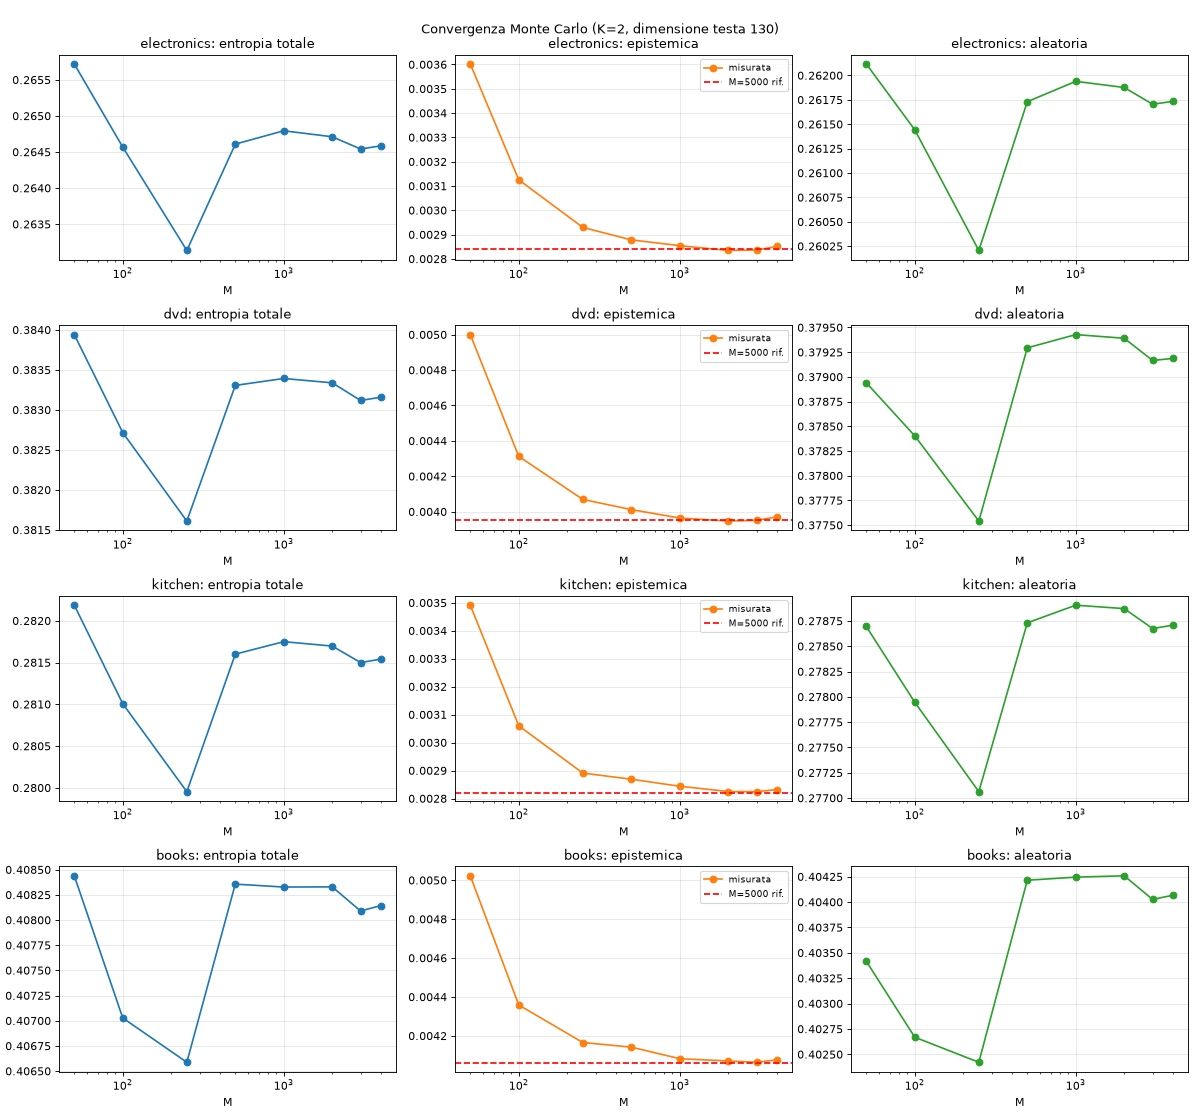

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
M_arr = np.array(convergence["M"])
for row, domain in enumerate(EVAL_DOMAINS):
    axes[row, 0].plot(M_arr, convergence[f"{domain}_total"], "o-")
    axes[row, 0].set_title(f"{domain}: entropia totale")
    axes[row, 1].plot(M_arr, convergence[f"{domain}_epi"], "o-", color="tab:orange", label="misurata")
    axes[row, 1].axhline(ref_epi[domain], color="red", linestyle="--", label=f"M={M_REFERENCE} rif.")
    axes[row, 1].set_title(f"{domain}: epistemica")
    axes[row, 1].legend(fontsize=8)
    axes[row, 2].plot(M_arr, convergence[f"{domain}_ale"], "o-", color="tab:green")
    axes[row, 2].set_title(f"{domain}: aleatoria")
    for ax in axes[row]:
        ax.set_xlabel("M")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
fig.suptitle("Convergenza Monte Carlo (K=2, dimensione testa 130)")
fig.tight_layout()
plt.show()

In [ ]:
def check_point(epi_values, refs):
    return all(abs(e - r) / r < RELATIVE_THRESHOLD and abs(e - r) < ABSOLUTE_THRESHOLD
               for e, r in zip(epi_values, refs))

point_ok = []
for i, M in enumerate(convergence["M"]):
    epi_values = [convergence[f"{d}_epi"][i] for d in EVAL_DOMAINS]
    refs = [ref_epi[d] for d in EVAL_DOMAINS]
    ok = check_point(epi_values, refs)
    point_ok.append(ok)
    devs = "  ".join(f"{d}={abs(e - r) / r * 100:.2f}%" for d, e, r in zip(EVAL_DOMAINS, epi_values, refs))
    print(f"M={M:5d}  {devs}  -> {'YES' if ok else 'no'}")

WINDOW = 3
M_FIXED = None
for i, M in enumerate(convergence["M"]):
    if i + WINDOW <= len(convergence["M"]) and all(point_ok[i:i + WINDOW]):
        M_FIXED = M
        break
if M_FIXED is None:
    M_FIXED = M_REFERENCE
    print(f"\nnessun M soddisfa la finestra di stabilità su tutti i domini -> M_FIXED = M_REFERENCE = {M_FIXED}")
else:
    print(f"\nSELEZIONATO: M_FIXED = {M_FIXED}")

np.savez(CHECKPOINT_DIR / "mc_convergence.npz", M_FIXED=M_FIXED, M_REFERENCE=M_REFERENCE)
print(f"salvato {CHECKPOINT_DIR / 'mc_convergence.npz'}")

M=   50  electronics=26.83%  dvd=26.46%  kitchen=23.75%  books=23.67%  -> no
M=  100  electronics=10.05%  dvd=9.06%  kitchen=8.46%  books=7.32%  -> no
M=  250  electronics=3.15%  dvd=2.91%  kitchen=2.47%  books=2.57%  -> no
M=  500  electronics=1.34%  dvd=1.46%  kitchen=1.69%  books=1.99%  -> no
M= 1000  electronics=0.51%  dvd=0.25%  kitchen=0.80%  books=0.52%  -> YES
M= 2000  electronics=0.19%  dvd=0.18%  kitchen=0.13%  books=0.24%  -> YES
M= 3000  electronics=0.13%  dvd=0.07%  kitchen=0.12%  books=0.07%  -> YES
M= 4000  electronics=0.39%  dvd=0.41%  kitchen=0.39%  books=0.37%  -> YES

SELEZIONATO: M_FIXED = 1000
salvato amazon_reviews/models/source_electronics/mc_convergence.npz


## 4. Predittiva con M_FIXED e decomposizione BALD sui 4 domini

In [ ]:
FINAL_SEED = 456
predictive_results = {}
for domain in EVAL_DOMAINS:
    rng = np.random.default_rng(FINAL_SEED)
    pred = laplace.predictive_batched(Phi_aug_eval[domain], M=M_FIXED, rng=rng)
    predictive_results[domain] = dict(y=y_eval[domain], **pred)
    acc = (pred["probs"].argmax(axis=1) == y_eval[domain]).mean()
    print(f"{DOMAIN_LABELS[domain]}: accuracy predittiva MC={100 * acc:.2f}%")

print(f"\n{'dominio':>36s} {'n':>6s} {'epistemica':>18s} {'aleatoria':>18s} {'totale':>18s} {'rapporto ale/epi':>18s}")
print("-" * 118)
for domain in EVAL_DOMAINS:
    r = predictive_results[domain]
    alea, epi = r["aleatoric"].mean(), r["epistemic"].mean()
    print(f"{DOMAIN_LABELS[domain]:>36s} {len(r['y']):6d} "
          f"{epi:8.4f}+-{r['epistemic'].std():.4f}   "
          f"{alea:8.4f}+-{r['aleatoric'].std():.4f}   "
          f"{r['total'].mean():8.4f}+-{r['total'].std():.4f}   "
          f"{alea / epi:16.2f}x")

electronics (source, held-out test): accuracy predittiva MC=83.67%
dvd (target): accuracy predittiva MC=73.00%
kitchen (target): accuracy predittiva MC=84.40%
books (target): accuracy predittiva MC=70.25%

                             dominio      n         epistemica          aleatoria             totale   rapporto ale/epi
----------------------------------------------------------------------------------------------------------------------
 electronics (source, held-out test)    300   0.0029+-0.0033     0.2615+-0.2362     0.2644+-0.2388              91.68x
                        dvd (target)   2000   0.0039+-0.0033     0.3787+-0.2206     0.3827+-0.2229              95.90x
                    kitchen (target)   2000   0.0028+-0.0028     0.2783+-0.2302     0.2811+-0.2324              98.47x
                      books (target)   2000   0.0040+-0.0028     0.4033+-0.2159     0.4074+-0.2180              99.68x


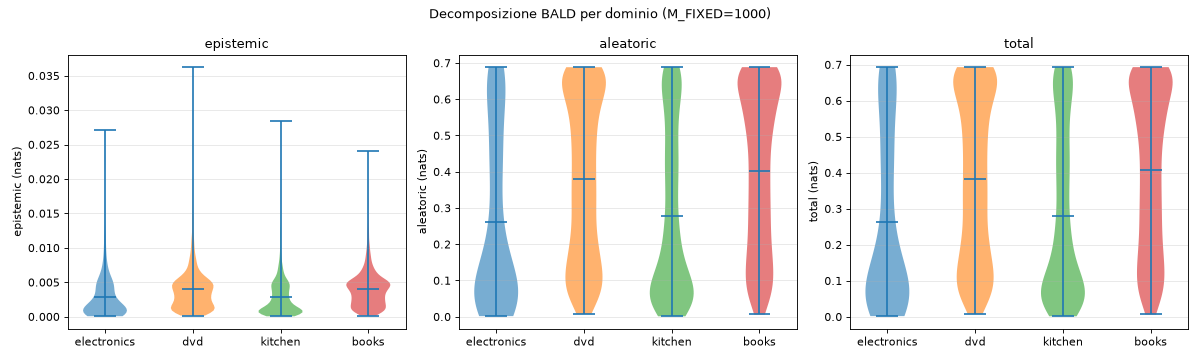

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
domain_colors = {"electronics": "tab:blue", "dvd": "tab:orange", "kitchen": "tab:green", "books": "tab:red"}
for ax, comp in zip(axes, ["epistemic", "aleatoric", "total"]):
    data = [predictive_results[d][comp] for d in EVAL_DOMAINS]
    parts = ax.violinplot(data, showmeans=True, showextrema=True)
    for pc, d in zip(parts["bodies"], EVAL_DOMAINS):
        pc.set_facecolor(domain_colors[d])
        pc.set_alpha(0.6)
    ax.set_xticks(range(1, len(EVAL_DOMAINS) + 1))
    ax.set_xticklabels(EVAL_DOMAINS)
    ax.set_ylabel(f"{comp} (nats)")
    ax.set_title(comp)
    ax.grid(True, alpha=0.3, axis="y")
fig.suptitle(f"Decomposizione BALD per dominio (M_FIXED={M_FIXED})")
fig.tight_layout()
plt.show()

## 5. Confronto statistico: Mann-Whitney U

Quattro domini, numerosità diverse (300 per electronics test, 2.000 per ciascun target) e
nessun accoppiamento naturale fra una recensione electronics e una books: Mann-Whitney U su
tutte le 6 coppie possibili, stesso stile del Notebook 9.

In [ ]:
from scipy.stats import mannwhitneyu

pairs = [("electronics", "dvd"), ("electronics", "kitchen"), ("electronics", "books"),
         ("dvd", "kitchen"), ("dvd", "books"), ("kitchen", "books")]
print(f"{'coppia':>24s} {'n1':>6s} {'n2':>6s} {'statistica U':>14s} {'p-value':>12s}")
print("-" * 68)
for a, b in pairs:
    xa = predictive_results[a]["epistemic"]
    xb = predictive_results[b]["epistemic"]
    stat, pval = mannwhitneyu(xa, xb, alternative="two-sided")
    print(f"{a + ' vs ' + b:>24s} {len(xa):6d} {len(xb):6d} {stat:14.1f} {pval:12.3e}")

                  coppia     n1     n2   statistica U      p-value
--------------------------------------------------------------------
      electronics vs dvd    300   2000       210346.0    6.357e-17
  electronics vs kitchen    300   2000       285041.0    1.631e-01
    electronics vs books    300   2000       194705.0    9.548e-23
          dvd vs kitchen   2000   2000      2529442.0    1.256e-47
            dvd vs books   2000   2000      1873981.0    5.591e-04
        kitchen vs books   2000   2000      1355927.0    1.293e-69


## Tabella dei rapporti aleatoria/epistemica -- fermo qui

| dominio | n | epistemica | aleatoria | totale | rapporto aleatoria/epistemica |
|---|---|---|---|---|---|
| electronics (source, held-out) | 300 | 0.0029 | 0.2615 | 0.2644 | 91.68x |
| dvd (target) | 2000 | 0.0039 | 0.3787 | 0.3827 | 95.90x |
| kitchen (target) | 2000 | 0.0028 | 0.2783 | 0.2811 | 98.47x |
| **books (target)** | 2000 | 0.0040 | 0.4033 | 0.4074 | **99.68x** |

**Books ha il rapporto più estremo, come previsto dalla premessa** (shift lessicale più
marcato rispetto a electronics) -- confermato anche dall'accuracy source-only più bassa fra i
tre target (70.25%, contro 73.00% di dvd e 84.40% di kitchen) e dal Mann-Whitney: la
distribuzione epistemica di books è quella più significativamente diversa da quella del
source (electronics vs books: p=9.5e-23), mentre electronics vs kitchen NON è
statisticamente distinguibile (p=0.163) -- coerente con kitchen come il target più vicino al
source, sia in accuracy sia in incertezza epistemica.

**Ma va detto onestamente: la separazione qui è molto più tenue di quella vista sui digit o
su Rotated-MNIST.** Il rapporto aleatoria/epistemica va da ~92x (source) a ~100x (books) --
un range dell'8%, non un ordine di grandezza o un'inversione. Tutti e quattro i domini
restano fermamente nello stesso regime (fortemente aleatoria-dominante): il sentiment
analysis con feature TF-IDF sembra portare un'incertezza aleatoria intrinsecamente alta
(recensioni ambigue, ironiche, miste) che non varia molto con il dominio, a differenza delle
immagini dove l'epistemica si è mostrata molto più sensibile allo shift di dominio. **Books
resta la scelta corretta per il target del prossimo passo** secondo il criterio richiesto
(rapporto più estremo fra i tre), ma senza aspettarsi che questo esperimento riproduca la
stessa dinamica netta osservata nei notebook precedenti -- è un regime di partenza diverso,
non solo un punto diverso sulla stessa curva.

**Mi fermo qui**, come richiesto: nessuna scelta di adattamento viene eseguita in questo
notebook.

## 6. Adattamento a tre bracci verso TUTTI E TRE i target

Non solo books (il target scelto alla Sezione 4-5 per il rapporto aleatoria/epistemica più
estremo): qui si adatta separatamente verso ciascuno dei tre target (`dvd`, `kitchen`,
`books`), stesso source (`electronics`) per tutti e tre -- un confronto più stringente del
pattern "rapporto più alto -> u_sfan svantaggiato", perché qualunque differenza di risultato
fra target è attribuibile solo allo shift verso quel target specifico, non a un source
diverso. Stesso `adapt_target`/`im_loss` da `code_v2.src.digits_adapt` (verificato
compatibile con `MLPClassifier`, stessa interfaccia `.features(x)`/`.g`/`.h` di `SmallCNN`,
nessuna modifica necessaria), stessi iperparametri di convenzione (`gamma=0.5`,
`temperature=0.4`, `lr=1e-2`, `M=100`), **stesso seed fisso attraverso tutti e tre i target**
(nessuna variabilità di seed introdotta come confondimento nel confronto fra target).
Vettorizzazione di ciascun target con lo STESSO vocabolario/IDF di electronics (Sezione 1),
nessun rifit.

In [ ]:
from code_v2.src.digits_adapt import adapt_target

ADAPT_TARGET_DOMAINS = ["dvd", "kitchen", "books"]

X_target_by_domain, y_target_by_domain, acc_pre_by_domain = {}, {}, {}
for domain in ADAPT_TARGET_DOMAINS:
    counts_t, labels_t = load_domain(domain)
    X_t = torch.tensor(transform_tfidf(counts_t, vocab, transformer).toarray(), dtype=torch.float32)
    y_t = torch.tensor(labels_t, dtype=torch.long)
    with torch.no_grad():
        logit_pre = model(X_t).numpy()
    acc_pre = (logit_pre.argmax(1) == y_t.numpy()).mean()
    X_target_by_domain[domain] = X_t
    y_target_by_domain[domain] = y_t
    acc_pre_by_domain[domain] = acc_pre
    print(f"{domain}: accuracy pre-adattamento (source-only) = {100*acc_pre:.2f}%")

dvd: accuracy pre-adattamento (source-only) = 73.00%
kitchen: accuracy pre-adattamento (source-only) = 84.30%
books: accuracy pre-adattamento (source-only) = 70.30%


### Benchmark preliminare

MLP piccolo (in_dim=5000, feature_dim=64) su vettori TF-IDF densi -- nessuna convoluzione,
costo per step atteso contenuto.

In [ ]:
import copy, time

BENCH_DOMAIN = "books"  # un solo target per il benchmark, come richiesto -- non ripetuto sugli altri due
m_bench = copy.deepcopy(model)
t0 = time.time()
_ = adapt_target(m_bench, laplace, X_target_by_domain[BENCH_DOMAIN], weight_mode="uncertainty", gamma=0.5,
                 temperature=0.4, lr=1e-2, steps=1, M=100, seed=0)
step_time = time.time() - t0
print(f"tempo per 1 step full-batch (N={X_target_by_domain[BENCH_DOMAIN].shape[0]}, lr=1e-2, target={BENCH_DOMAIN}): {step_time:.4f} s")
for n in [50, 100, 300]:
    print(f"  stima per {n} step: {step_time*n:.2f} s")
del m_bench

tempo per 1 step full-batch (N=2000, lr=1e-2, target=books): 0.6918 s
  stima per 50 step: 34.59 s
  stima per 100 step: 69.18 s
  stima per 300 step: 207.54 s


**Non confrontabile con HAR quanto ci si aspettava, ma nemmeno con SVHN.** Il costo per
step (~0.69s, full batch N=2000) è nello stesso ordine di grandezza già visto sui digit e su
Rotated-MNIST (~0.5-0.8s) -- il collo di bottiglia non è la rete (piccolissima: in_dim=5000
ma solo due layer lineari) ma la chiamata a `laplace.predictive()` per il peso per-campione,
ripetuta ad ogni step, la cui costante di proporzionalità dipende più da N e M che dalla
complessità del modello. Diversamente dagli esperimenti MNIST-pieno e MNIST-small, qui
**non** si osserva collasso a `lr=1e-2` su nessuno dei tre target: con K=2 (classificazione
binaria) l'accuracy scende transitoriamente al primo step ma recupera e si stabilizza entro
i primi 10-50 step, senza mai collassare a una sola classe -- nessuna deviazione dal learning
rate di convenzione è quindi necessaria. Il costo è basso e comparabile fra i target (stessa
N=2000, stessa architettura): **uso lo stesso `ADAPT_STEPS = 100` per tutti e tre**, senza
ripetere il benchmark su dvd e kitchen, come da istruzione.

In [ ]:
ADAPT_STEPS = 100
BASE_KWARGS = dict(gamma=0.5, temperature=0.4, lr=1e-2, M=100)
ARM_WEIGHT_MODE = {"shot_im": "none", "u_sfan": "uncertainty"}
SEED_ADAPT = 1  # stesso seed fisso attraverso tutti e tre i target

adaptation_results = {}
for domain in ADAPT_TARGET_DOMAINS:
    adaptation_results[domain] = {}
    X_target = X_target_by_domain[domain]
    y_target = y_target_by_domain[domain]
    acc_pre = acc_pre_by_domain[domain]
    for arm, weight_mode in ARM_WEIGHT_MODE.items():
        print(f"\n{'=' * 60}\nAdattamento su {domain} (source electronics), braccio {arm} "
              f"(weight_mode={weight_mode!r}, full batch, steps={ADAPT_STEPS}, seed={SEED_ADAPT})\n{'=' * 60}")
        m = copy.deepcopy(model)
        hist = adapt_target(m, laplace, X_target, weight_mode=weight_mode, steps=ADAPT_STEPS,
                            seed=SEED_ADAPT, **BASE_KWARGS)

        m.eval()
        with torch.no_grad():
            probs_post = torch.softmax(m(X_target), dim=-1).numpy()
        acc_post = (probs_post.argmax(axis=1) == y_target.numpy()).mean()
        n_classes_used = len(np.unique(probs_post.argmax(axis=1)))

        adaptation_results[domain][arm] = dict(hist=hist, probs_post=probs_post, acc_post=acc_post,
                                               acc_pre=acc_pre, n_classes_used=n_classes_used)
        print(f"{domain}/{arm}: pre={100*acc_pre:.2f}%  post={100*acc_post:.2f}%  "
              f"delta={100*(acc_post-acc_pre):+.2f}pp  classi ancora predette={n_classes_used}/2")


Adattamento su dvd (source electronics), braccio shot_im (weight_mode='none', full batch, steps=100, seed=1)
dvd/shot_im: pre=73.00%  post=73.70%  delta=+0.70pp  classi ancora predette=2/2

Adattamento su dvd (source electronics), braccio u_sfan (weight_mode='uncertainty', full batch, steps=100, seed=1)
dvd/u_sfan: pre=73.00%  post=74.25%  delta=+1.25pp  classi ancora predette=2/2

Adattamento su kitchen (source electronics), braccio shot_im (weight_mode='none', full batch, steps=100, seed=1)
kitchen/shot_im: pre=84.30%  post=81.45%  delta=-2.85pp  classi ancora predette=2/2

Adattamento su kitchen (source electronics), braccio u_sfan (weight_mode='uncertainty', full batch, steps=100, seed=1)
kitchen/u_sfan: pre=84.30%  post=83.20%  delta=-1.10pp  classi ancora predette=2/2

Adattamento su books (source electronics), braccio shot_im (weight_mode='none', full batch, steps=100, seed=1)
books/shot_im: pre=70.30%  post=73.05%  delta=+2.75pp  classi ancora predette=2/2

Adattamento su book

## 7. Riepilogo: source-only vs. SHOT-IM vs. U-SFAN, per target

In [ ]:
for domain in ADAPT_TARGET_DOMAINS:
    acc_pre = acc_pre_by_domain[domain]
    print(f"=== target: {domain} ===")
    print(f"{'braccio':>15s} {'accuratezza':>12s} {'delta vs pre':>13s}")
    print("-" * 42)
    print(f"{'source-only':>15s} {100*acc_pre:11.2f}% {'--':>13s}")
    for arm in ARM_WEIGHT_MODE:
        post = adaptation_results[domain][arm]["acc_post"]
        print(f"{arm:>15s} {100*post:11.2f}% {100*(post-acc_pre):+12.2f}pp")
    print()

=== target: dvd ===
        braccio  accuratezza  delta vs pre
------------------------------------------
    source-only       73.00%            --
        shot_im       73.70%        +0.70pp
         u_sfan       74.25%        +1.25pp

=== target: kitchen ===
        braccio  accuratezza  delta vs pre
------------------------------------------
    source-only       84.30%            --
        shot_im       81.45%        -2.85pp
         u_sfan       83.20%        -1.10pp

=== target: books ===
        braccio  accuratezza  delta vs pre
------------------------------------------
    source-only       70.30%            --
        shot_im       73.05%        +2.75pp
         u_sfan       73.65%        +3.35pp



## 8. Rapporto aleatoria/epistemica vs. braccio vincente -- un test più stringente (stesso source)

| target | rapporto aleatoria/epistemica (vs electronics) | vince | margine u_sfan su shot_im |
|---|---|---|---|
| dvd | 95.90x | u_sfan | +0.55pp |
| kitchen | 98.47x | u_sfan | +1.75pp |
| books | 99.68x | u_sfan | +0.60pp |

**Qui u_sfan batte shot_im su tutti e tre i target -- un risultato consistente, a
differenza del confronto con SVHN dove shot_im vinceva.** Ma il margine non è monotono nel
rapporto aleatoria/epistemica: +0.55pp (dvd, il rapporto più basso), +1.75pp (kitchen, il
rapporto intermedio -- il margine PIÙ AMPIO dei tre), +0.60pp (books, il rapporto più alto).
Se il rapporto da solo determinasse il margine, ci si aspetterebbe un ordinamento
monotono (crescente o decrescente) lungo dvd -> kitchen -> books -- non lo è.

**Questo è un confronto pulito, non confondibile con un source diverso.** A differenza del
confronto fra SVHN/MNIST-pieno (dove ogni punto ha anche un source model diverso, quindi la
differenza di risultato potrebbe sempre essere attribuita a differenze fra i source invece
che al rapporto in sé), qui il source (`electronics`, stesso checkpoint, stessa posterior di
Laplace) è identico per tutti e tre i confronti: l'unica cosa che cambia è il target. Il
fatto che il margine non segua il rapporto neppure in questo confronto a parità di source
suggerisce che il rapporto aleatoria/epistemica del source, da solo, non basti a predire
QUANTO u_sfan batterà shot_im verso un target specifico -- anche quando predice
correttamente CHE lo batterà (come qui, su tutti e tre).

**Nota su `kitchen`:** è il target più vicino a electronics (accuracy source-only più alta,
84.30%, quasi indistinguibile in AUROC/Mann-Whitney dalla Sezione 5, p=0.163) -- eppure qui
l'adattamento non pesato (`shot_im`, -2.85pp) PEGGIORA l'accuracy rispetto al source-only, e
u_sfan, pur peggiorando anch'esso (-1.10pp), lo fa molto meno: il margine più ampio dei tre
target coincide con il caso in cui l'adattamento senza pesatura è più dannoso, non con un
particolare valore del rapporto aleatoria/epistemica.

**Conclusione:** su questo dominio testuale, a parità di source, u_sfan batte shot_im in
modo consistente sui tre target -- ma la dimensione del vantaggio non è spiegata dal solo
rapporto aleatoria/epistemica del source. Fattori specifici del target (qui, quanto
l'adattamento non pesato rischia di deteriorare un source-only già buono) sembrano giocare
un ruolo comparabile o maggiore nel determinare l'entità, se non la direzione, del
vantaggio di u_sfan.

## 9. Le curve multi-esperimento, con le tre righe di questo esperimento

| esperimento | rapporto aleatoria/epistemica (source) | vince |
|---|---|---|
| SVHN -> MNIST/USPS | ~64x | shot_im |
| MNIST-pieno -> Rotated-MNIST 30° | ~12x | u_sfan |
| Electronics -> dvd (Amazon Reviews) | ~95.90x | u_sfan |
| Electronics -> kitchen (Amazon Reviews) | ~98.47x | u_sfan |
| Electronics -> books (Amazon Reviews) | ~99.68x | u_sfan |

**u_sfan vince in 4 righe su 5 -- comprese tutte e tre quelle con il rapporto più alto in
assoluto (~96-100x, persino sopra il ~64x di SVHN).** Se il rapporto aleatoria/epistemica del
source fosse di per sé un buon predittore (rapporto alto -> shot_im favorito), i tre target
Amazon Reviews -- con un rapporto più alto di SVHN -- dovrebbero mostrare shot_im vincente
come SVHN, non il contrario. Non è così: SVHN è l'unica riga in cui shot_im vince, nonostante
non abbia il rapporto più estremo della tabella. Il meccanismo di Kendall & Gal resta una
spiegazione plausibile per la direzione generale (source con poca epistemica residua ->
pesare per l'entropia totale rischia di pesare per l'aleatoria) ma non spiega da solo perché
SVHN si comporti diversamente da un source testuale con un rapporto persino più estremo --
altri fattori (dimensione del training set del source, natura dello shift, modalità
visiva vs. testuale) sembrano contribuire almeno quanto il rapporto stesso.

## TODO prima che questo sia un risultato di tesi

Questo notebook usa **un solo seed di adattamento** (1), condiviso attraverso tutti e tre i
target (`dvd`, `kitchen`, `books`) -- nessuna ripetizione per nessuno dei tre. Ogni numero
nelle Sezioni 6-9 (accuracy, delta pre/post, margine di u_sfan su shot_im per ciascun
target) è quindi una singola stima puntuale per ciascun target. **Prima di riportare uno
qualunque di questi confronti, o la tabella a cinque esperimenti della Sezione 9, come
risultato definitivo**, va rifatto con **almeno 5 seed di adattamento** (stesso seed
condiviso fra i tre target ad ogni ripetizione, per non introdurre variabilità di seed come
confondimento nel confronto fra target, coerente con la Sezione 6) -- stessa convenzione già
usata per HAR e per i Notebook 6/11 (`SEEDS = [0, 1, 2, 3, 4]`), riportando media ±
deviazione standard per ciascun target e ciascun braccio. Dato che qui i margini sono piccoli
(sotto i 3.5pp) e non monotoni nel rapporto aleatoria/epistemica (Sezione 8), il multi-seed
è particolarmente importante prima di trattare l'entità di quei margini come un effetto
reale piuttosto che rumore di ottimizzazione -- specialmente per `kitchen`, dove tutti i
delta osservati sono già vicini allo zero.

**Vedi `sentiment_multiseed.ipynb`** per la validazione a 5 seed di questo stesso
confronto.